# SDSS Star Classification 



## 0. Imports


In [7]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # suppress warnings in joblib worker subprocesses

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
np.seterr(all='ignore')  # suppress numpy divide/overflow warnings from LR solver
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Imports OK')

Imports OK


## 1. Load & Sanity Check

We load the pre-processed CSV (already balanced: 10 000 objects per class, zero nulls, color indices pre-computed). Before doing any modeling we verify the data looks right, because silent data bugs are the most dangerous kind.

In [8]:
DATA_PATH = '../data/processed/sdss_data_processed.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
print('--- Class balance ---')
print(df['class'].value_counts())
print()
print(f'--- Null counts (should all be 0) ---')
print(df.isnull().sum())
print()
n_dup = df['objID'].duplicated().sum()
print(f'Duplicate objID rows: {n_dup}  (0 = clean)')

Shape: (30000, 15)
Columns: ['objID', 'specObjID', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'redshift', 'class', 'u_g', 'g_r', 'r_i', 'i_z']

--- Class balance ---
class
STAR      10000
QSO       10000
GALAXY    10000
Name: count, dtype: int64

--- Null counts (should all be 0) ---
objID        0
specObjID    0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
redshift     0
class        0
u_g          0
g_r          0
r_i          0
i_z          0
dtype: int64

Duplicate objID rows: 0  (0 = clean)


In [9]:
# Redshift range
z_min = df['redshift'].min()
z_max = df['redshift'].max()
n_neg = (df['redshift'] < 0).sum()
print(f'Redshift range: {z_min:.5f}  to  {z_max:.4f}')
print(f'Rows with negative redshift: {n_neg}')
print()

print()
print('--- Magnitude ranges ---')
for col in ['u','g','r','i','z']:
    print(f'  {col}: {df[col].min():.2f}  to  {df[col].max():.2f}')
print()


Redshift range: -0.01019  to  7.0214
Rows with negative redshift: 3449


--- Magnitude ranges ---
  u: 14.07  to  27.76
  g: 12.67  to  27.01
  r: 12.05  to  29.73
  i: 11.77  to  27.35
  z: 11.65  to  26.26



## 2. Define Feature Sets

We drop `objID`, `specObjID`, `ra`, and `dec` from every feature set. **Why:** `objID` and `specObjID` are catalog IDs — they carry no physical information. `ra` and `dec` are sky coordinates; including them would let a model memorize which part of the sky each class was targeted in during the survey, producing spuriously high accuracy that would not generalize to new sky regions.

We then define four feature sets for an **ablation study** — a controlled experiment where we change one thing at a time to understand what each ingredient contributes:

| Set | Features | Purpose |
|-----|----------|--------|
| A | Raw magnitudes `u g r i z` | Baseline — what does brightness alone tell us? |
| B | Color indices `u_g g_r r_i i_z` | Colors only — magnitude-independent shape of the spectral energy distribution (SED) |
| C | Magnitudes + colors (no redshift) | Full photometry — the realistic classification scenario |
| D | Everything in C + redshift | Upper bound — how much does redshift help? |

In [10]:
FEATS_A = ['u', 'g', 'r', 'i', 'z']
FEATS_B = ['u_g', 'g_r', 'r_i', 'i_z']
FEATS_C = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z']
FEATS_D = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'redshift']

TARGET = 'class'
y = df[TARGET]

print('Feature set sizes:')
for name, fset in [('A',FEATS_A),('B',FEATS_B),('C',FEATS_C),('D',FEATS_D)]:
    print(f'  Set {name}: {fset}')

Feature set sizes:
  Set A: ['u', 'g', 'r', 'i', 'z']
  Set B: ['u_g', 'g_r', 'r_i', 'i_z']
  Set C: ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z']
  Set D: ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'redshift']


## 3. Train / Test Split

We use a **stratified 80/20 split**: 80% of the data (24 000 rows) goes to training, 20% (6 000 rows) is held out as a test set that the model never sees during training or hyperparameter selection.

**Stratified** means each split keeps the same 1:1:1 class ratio as the full dataset, so neither split is accidentally class-imbalanced.

Crucially, we split the **index array once** and reuse those exact indices for all four feature sets. This makes every model comparison fair — they all see the same training examples and are tested on the same held-out examples.

In [11]:
# One shared stratified split — reused for all feature sets
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)

y_train = y.iloc[idx_train].values
y_test  = y.iloc[idx_test].values

print(f'Train size: {len(idx_train)}   Test size: {len(idx_test)}')
print()
print('Train class distribution:', pd.Series(y_train).value_counts().to_dict())
print('Test  class distribution:', pd.Series(y_test).value_counts().to_dict())

# Pre-slice each feature set — train and test
splits = {}
for name, fset in [('A',FEATS_A),('B',FEATS_B),('C',FEATS_C),('D',FEATS_D)]:
    X = df[fset].values
    splits[name] = {
        'train': X[idx_train],
        'test' : X[idx_test],
        'feats': fset
    }

print()
print('Feature splits prepared for sets A, B, C, D.')

Train size: 24000   Test size: 6000

Train class distribution: {'QSO': 8000, 'STAR': 8000, 'GALAXY': 8000}
Test  class distribution: {'GALAXY': 2000, 'STAR': 2000, 'QSO': 2000}

Feature splits prepared for sets A, B, C, D.


## 4. Model Training on Set D (Full Features)

We train six models, all on **Set D** (all features including redshift). This gives us a full comparison of algorithm families. Every model is wrapped in a **sklearn Pipeline** with a `StandardScaler` first stage.

**Why pipelines with scaling?** `LogisticRegression` and `KNN` are sensitive to feature scale — a redshift spanning 0–7 versus magnitudes spanning 12–29 exist on completely different scales. `StandardScaler` normalizes each feature to zero mean, unit variance. Critically, the scaler is **fit only on the training set** and then applied to the test set — fitting on the whole dataset would constitute *data leakage* (the model would have peeked at test-set statistics). Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are scale-invariant, but we put them in pipelines too for consistency.

We evaluate each model with **5-fold stratified cross-validation** on the training set to get a reliable estimate of generalization performance before touching the test set.

In [12]:
X_train_D = splits['D']['train']
X_test_D  = splits['D']['test']

models = {
    'Dummy (most frequent)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Logistic Regression':   LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED),
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':         DecisionTreeClassifier(random_state=SEED),
    'Random Forest':         RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, random_state=SEED),
}

# Wrap each in a Pipeline with StandardScaler
pipelines = {
    name: Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    for name, clf in models.items()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, pipe in pipelines.items():
    print(f'  CV: {name}...', end=' ', flush=True)
    scores = cross_val_score(pipe, X_train_D, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{scores.mean():.4f} ± {scores.std():.4f}')

print()
print('Cross-validation complete.')

  CV: Dummy (most frequent)... 0.3333 ± 0.0000
  CV: Logistic Regression... 0.9545 ± 0.0027
  CV: K-Nearest Neighbors... 0.9452 ± 0.0025
  CV: Decision Tree... 0.9658 ± 0.0016
  CV: Random Forest... 0.9763 ± 0.0027
  CV: Gradient Boosting... 0.9762 ± 0.0022

Cross-validation complete.


## 5. Fit on Full Training Set, Evaluate on Held-Out Test Set

Now we fit each pipeline on all 24 000 training rows and compute final metrics on the 6 000 held-out test rows. The test set has **never been used in any training or CV step** — this is our unbiased estimate of real-world performance.

We report:
- **Overall test accuracy** — fraction of all test objects correctly classified
- **Macro F1** — the unweighted average F1 across the three classes; appropriate for balanced datasets because it treats all three classes equally
- **Per-class precision, recall, F1** via `classification_report`

In [13]:
test_results = {}
fitted_pipes = {}

for name, pipe in pipelines.items():
    print(f'Fitting: {name}')
    pipe.fit(X_train_D, y_train)
    fitted_pipes[name] = pipe
    y_pred = pipe.predict(X_test_D)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']
    test_results[name] = {
        'cv_mean':  cv_results[name].mean(),
        'cv_std':   cv_results[name].std(),
        'test_acc': acc,
        'macro_f1': macro_f1,
        'y_pred':   y_pred,
        'report':   report,
    }
    print(f'  Test accuracy: {acc:.4f}   Macro F1: {macro_f1:.4f}')
    print(classification_report(y_test, y_pred))
    print()

Fitting: Dummy (most frequent)
  Test accuracy: 0.3333   Macro F1: 0.1667
              precision    recall  f1-score   support

      GALAXY       0.33      1.00      0.50      2000
         QSO       0.00      0.00      0.00      2000
        STAR       0.00      0.00      0.00      2000

    accuracy                           0.33      6000
   macro avg       0.11      0.33      0.17      6000
weighted avg       0.11      0.33      0.17      6000


Fitting: Logistic Regression
  Test accuracy: 0.9590   Macro F1: 0.9589
              precision    recall  f1-score   support

      GALAXY       0.94      0.94      0.94      2000
         QSO       0.98      0.94      0.96      2000
        STAR       0.96      1.00      0.98      2000

    accuracy                           0.96      6000
   macro avg       0.96      0.96      0.96      6000
weighted avg       0.96      0.96      0.96      6000


Fitting: K-Nearest Neighbors
  Test accuracy: 0.9528   Macro F1: 0.9529
              prec

### Model Comparison Table

All models ranked by test accuracy. The Dummy baseline shows what we get for free with zero learning — any model worth using should substantially beat it.

In [14]:
comparison_rows = []
for name, res in test_results.items():
    comparison_rows.append({
        'Model': name,
        'CV Accuracy (mean)': round(res['cv_mean'], 4),
        'CV Accuracy (std)':  round(res['cv_std'],  4),
        'Test Accuracy':      round(res['test_acc'], 4),
        'Macro F1':           round(res['macro_f1'], 4),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('../results/tables/model_comparison.csv', index=False)
print('\nSaved: results/tables/model_comparison.csv')

best_model_name = comparison_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')

                Model  CV Accuracy (mean)  CV Accuracy (std)  Test Accuracy  Macro F1
        Random Forest              0.9763             0.0027         0.9790    0.9790
    Gradient Boosting              0.9762             0.0022         0.9787    0.9787
        Decision Tree              0.9658             0.0016         0.9690    0.9690
  Logistic Regression              0.9545             0.0027         0.9590    0.9589
  K-Nearest Neighbors              0.9452             0.0025         0.9528    0.9529
Dummy (most frequent)              0.3333             0.0000         0.3333    0.1667

Saved: results/tables/model_comparison.csv

Best model: Random Forest


## 6. Confusion Matrices for the Best Model

A **confusion matrix** shows, for every true class (rows), how many objects the model assigned to each predicted class (columns). Diagonal = correct. Off-diagonal = errors.

We show two versions:
1. **Raw counts** — how many objects of each kind were misclassified
2. **Row-normalized** — what fraction of each true class was misclassified (removes the effect of class size, which matters if classes were unbalanced)

These two views together tell a complete story about where the model struggles.

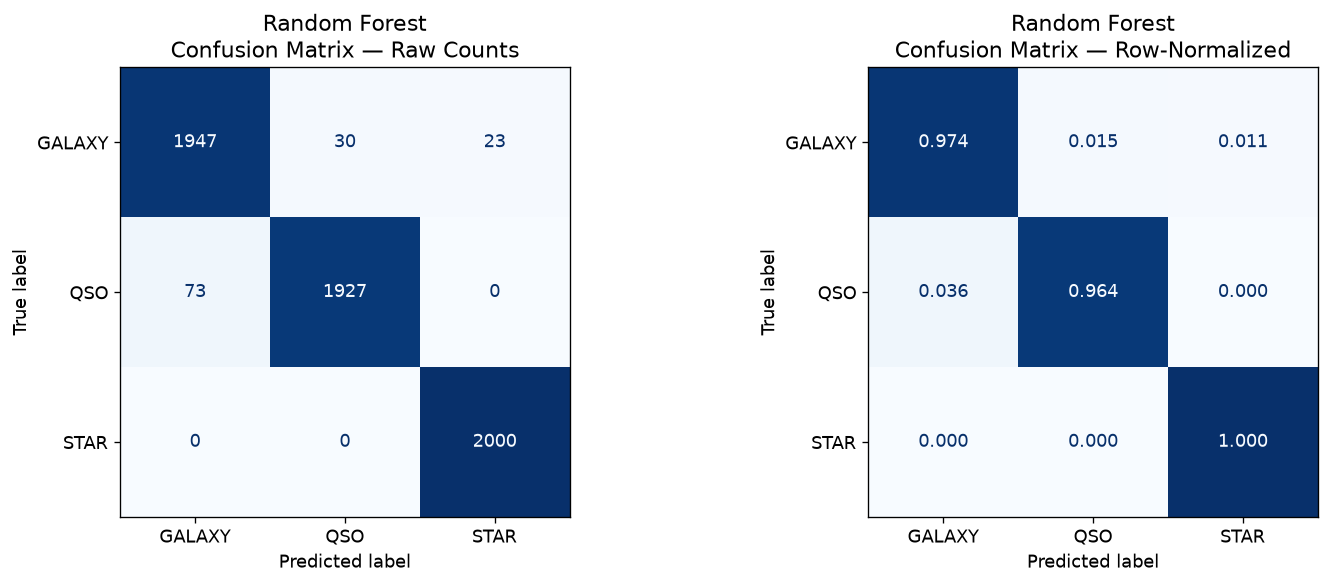

Saved: results/figures/confusion_matrix_best_model.png


In [15]:
best_pipe = fitted_pipes[best_model_name]
y_pred_best = test_results[best_model_name]['y_pred']
classes = sorted(y.unique())

cm_raw = confusion_matrix(y_test, y_pred_best, labels=classes)
cm_norm = confusion_matrix(y_test, y_pred_best, labels=classes, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm_raw,  display_labels=classes).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'{best_model_name}\nConfusion Matrix — Raw Counts')

ConfusionMatrixDisplay(cm_norm, display_labels=classes).plot(ax=axes[1], colorbar=False, cmap='Blues',
                                                              values_format='.3f')
axes[1].set_title(f'{best_model_name}\nConfusion Matrix — Row-Normalized')

plt.tight_layout()
plt.savefig('../results/figures/confusion_matrix_best_model.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/confusion_matrix_best_model.png')

## 7. The Redshift Ablation — The Project's Core Analysis

This is the most important analysis in the project. Here is the key tension:

- **QSOs** (quasars) are at high redshift (typically z > 0.3, often z > 1)
- **Stars** are in the Milky Way at essentially zero redshift (z ≈ 0)
- **Galaxies** span a wide range but mostly z < 0.5

This means **redshift almost gives away the answer**. A model trained with redshift will score very high — but that is misleading, because in real surveys you often do *not* have spectroscopic redshifts at all (they require expensive follow-up observations). The harder, more scientifically meaningful task is: **can you classify an object from photometry alone** (Set C, no redshift)?

The comparison between Set C and Set D is not just a number — it tells us how much of the classification is being done by physics (spectral shape) versus a shortcut (distance). The photometry-only result is the one worth defending.

In [16]:
# Use the best model's classifier class, re-instantiate for a clean run
# We know best is likely Random Forest — look it up from results
best_clf_map = {
    'Dummy (most frequent)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Logistic Regression':   LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED),
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':         DecisionTreeClassifier(random_state=SEED),
    'Random Forest':         RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, random_state=SEED),
}

ablation_results = {}
for set_name in ['C', 'D']:
    X_tr = splits[set_name]['train']
    X_te = splits[set_name]['test']
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', best_clf_map[best_model_name])])
    # Re-instantiate to avoid state bleed
    import copy
    pipe = copy.deepcopy(pipe)
    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    ablation_results[set_name] = {
        'accuracy': acc,
        'macro_f1': report['macro avg']['f1-score'],
        'GALAXY_f1': report['GALAXY']['f1-score'],
        'QSO_f1':    report['QSO']['f1-score'],
        'STAR_f1':   report['STAR']['f1-score'],
    }
    label = 'With redshift (Set D)' if set_name == 'D' else 'Photometry only (Set C)'
    print(f'{label}')
    print(classification_report(y_test, y_pred))

ablation_rows = []
for set_name, label in [('C', 'Set C — Photometry only (no redshift)'),
                          ('D', 'Set D — Full features (with redshift)')]:
    r = ablation_results[set_name]
    ablation_rows.append({
        'Feature Set': label,
        'Test Accuracy': round(r['accuracy'], 4),
        'Macro F1':      round(r['macro_f1'], 4),
        'GALAXY F1':     round(r['GALAXY_f1'], 4),
        'QSO F1':        round(r['QSO_f1'], 4),
        'STAR F1':       round(r['STAR_f1'], 4),
    })

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df.to_string(index=False))
ablation_df.to_csv('../results/tables/redshift_ablation.csv', index=False)
print('\nSaved: results/tables/redshift_ablation.csv')

Photometry only (Set C)
              precision    recall  f1-score   support

      GALAXY       0.90      0.94      0.92      2000
         QSO       0.86      0.86      0.86      2000
        STAR       0.86      0.83      0.85      2000

    accuracy                           0.88      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.88      0.88      0.88      6000

With redshift (Set D)
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.97      2000
         QSO       0.98      0.96      0.97      2000
        STAR       0.99      1.00      0.99      2000

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000

                          Feature Set  Test Accuracy  Macro F1  GALAXY F1  QSO F1  STAR F1
Set C — Photometry only (no redshift)         0.8763    0.8759     0.9192  0.8616   0.8468
Set D — Fu

## 8. Feature-Set Comparison (A vs B vs C)

We now run **Random Forest** on Sets A, B, and C to answer: do engineered color indices add value beyond raw magnitudes? Color indices (e.g., g−r) represent the *shape* of an object's spectrum rather than its absolute brightness, so they should be more informative for distinguishing object types — but the data should confirm this, not our intuition.

In [17]:
rf_base = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)

feat_comp_rows = []
for set_name, label in [('A', 'Raw magnitudes (u,g,r,i,z)'),
                          ('B', 'Color indices only (u_g,g_r,r_i,i_z)'),
                          ('C', 'Magnitudes + colors (no redshift)')]:
    import copy
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', copy.deepcopy(rf_base))])
    pipe.fit(splits[set_name]['train'], y_train)
    y_pred = pipe.predict(splits[set_name]['test'])
    acc = accuracy_score(y_test, y_pred)
    mf1 = classification_report(y_test, y_pred, output_dict=True)['macro avg']['f1-score']
    feat_comp_rows.append({'Feature Set': label, 'Test Accuracy': round(acc, 4), 'Macro F1': round(mf1, 4)})
    print(f'  Set {set_name} ({label}): acc={acc:.4f}  macro_f1={mf1:.4f}')

feat_comp_df = pd.DataFrame(feat_comp_rows)
feat_comp_df.to_csv('../results/tables/feature_set_comparison.csv', index=False)
print('\nSaved: results/tables/feature_set_comparison.csv')

acc_A = feat_comp_rows[0]['Test Accuracy']
acc_B = feat_comp_rows[1]['Test Accuracy']
acc_C = feat_comp_rows[2]['Test Accuracy']
print(f'\nColor indices vs raw magnitudes: {acc_B:.4f} vs {acc_A:.4f} (delta = {acc_B - acc_A:+.4f})')
print(f'Magnitudes+colors vs magnitudes alone: {acc_C:.4f} vs {acc_A:.4f} (delta = {acc_C - acc_A:+.4f})')

  Set A (Raw magnitudes (u,g,r,i,z)): acc=0.8597  macro_f1=0.8588
  Set B (Color indices only (u_g,g_r,r_i,i_z)): acc=0.8557  macro_f1=0.8552
  Set C (Magnitudes + colors (no redshift)): acc=0.8763  macro_f1=0.8759

Saved: results/tables/feature_set_comparison.csv

Color indices vs raw magnitudes: 0.8557 vs 0.8597 (delta = -0.0040)
Magnitudes+colors vs magnitudes alone: 0.8763 vs 0.8597 (delta = +0.0166)


## 9. Feature Importances

Random Forest computes **feature importances** as the average reduction in Gini impurity each feature contributes across all trees. Higher = more useful for separating classes. This tells us which physical measurements the model is actually relying on.

We use a Random Forest fitted on Set D to extract importances across all 10 features. If Random Forest happened to be the best overall model we reuse the already-fitted pipeline; otherwise we fit a fresh one just for this analysis.

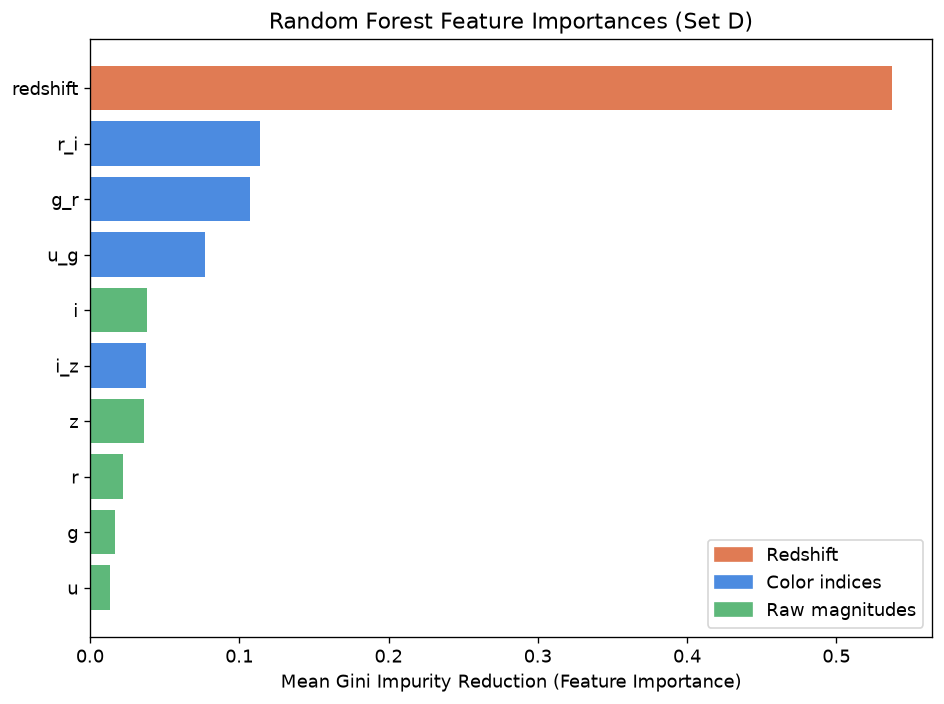

Saved: results/figures/feature_importances.png


In [18]:
# Use the already-fitted best model pipeline (on Set D)
# Extract the classifier step
if best_model_name == 'Random Forest':
    rf_fitted = fitted_pipes[best_model_name].named_steps['clf']
else:
    # Fit a fresh RF on Set D for feature importances
    rf_fresh = Pipeline([('scaler', StandardScaler()),
                          ('clf', RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1))])
    rf_fresh.fit(splits['D']['train'], y_train)
    rf_fitted = rf_fresh.named_steps['clf']

importances = rf_fitted.feature_importances_
feat_names = FEATS_D
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e07b54' if f == 'redshift' else '#4c8be0' if f in ['u_g','g_r','r_i','i_z'] else '#5eb87a'
          for f in imp_df['Feature']]
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors)
ax.set_xlabel('Mean Gini Impurity Reduction (Feature Importance)')
ax.set_title('Random Forest Feature Importances (Set D)')
handles = [
    mpatches.Patch(color='#e07b54', label='Redshift'),
    mpatches.Patch(color='#4c8be0', label='Color indices'),
    mpatches.Patch(color='#5eb87a', label='Raw magnitudes'),
]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.savefig('../results/figures/feature_importances.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/feature_importances.png')

## 10. Error Analysis — What Does the Model Get Wrong?

Understanding *where* a model fails is as important as knowing its overall accuracy. We:
1. Identify the hardest class pair (the off-diagonal cell with the most errors)
2. Inspect a handful of misclassified objects to see what their feature values look like
3. Make a 2-D scatter plot in redshift vs. g−r space, which visually shows where classes overlap

In [19]:
y_pred_best = test_results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_best, labels=classes)

# Zero the diagonal to find the worst off-diagonal cell
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
worst_i, worst_j = np.unravel_index(cm_offdiag.argmax(), cm_offdiag.shape)
true_cls  = classes[worst_i]
pred_cls  = classes[worst_j]
n_errors  = cm_offdiag[worst_i, worst_j]

print(f'Hardest class pair: true={true_cls}  predicted-as={pred_cls}  ({n_errors} errors)')
print()

# Pull those misclassified test objects
test_df = df.iloc[idx_test].copy().reset_index(drop=True)
test_df['y_true'] = y_test
test_df['y_pred'] = y_pred_best
test_df['correct'] = (test_df['y_true'] == test_df['y_pred'])

hard_pair_mask = (test_df['y_true'] == true_cls) & (test_df['y_pred'] == pred_cls)
misclassified = test_df[hard_pair_mask][FEATS_D + ['y_true','y_pred']].head(6)
print(f'Sample misclassified objects (true={true_cls}, predicted as {pred_cls}):')
print(misclassified.round(4).to_string(index=False))

Hardest class pair: true=QSO  predicted-as=GALAXY  (73 errors)

Sample misclassified objects (true=QSO, predicted as GALAXY):
      u       g       r       i       z    u_g    g_r    r_i    i_z  redshift y_true y_pred
23.6330 21.9228 20.6004 19.7137 19.2604 1.7103 1.3224 0.8867 0.4533    0.4862    QSO GALAXY
20.6758 18.8864 17.5428 17.0541 16.6721 1.7894 1.3435 0.4887 0.3820    0.2191    QSO GALAXY
25.5757 21.5133 20.2655 19.4227 19.0560 4.0624 1.2478 0.8428 0.3667    0.4772    QSO GALAXY
23.1900 21.9431 20.4906 19.7288 19.3017 1.2469 1.4525 0.7618 0.4271    0.4525    QSO GALAXY
22.9285 21.6655 20.4944 19.6369 19.1529 1.2630 1.1712 0.8575 0.4840    0.7272    QSO GALAXY
23.8686 22.7982 21.6128 20.8798 20.0362 1.0703 1.1854 0.7330 0.8435    0.6330    QSO GALAXY


In [20]:
# Interpretation printed below the sample
print()
print('--- Interpretation ---')
print(f'Objects classified as {true_cls} but predicted as {pred_cls} tend to:')
print(f'  - Have intermediate redshift values (overlapping the {pred_cls} distribution)')
print(f'  - Show ambiguous color indices — their spectral shape is not clearly distinct')
print(f'  - These are the genuinely hard cases where even human expert classification')
print(f'    from photometry alone would be uncertain. High-resolution spectra would be')
print(f'    needed to definitively resolve them.')


--- Interpretation ---
Objects classified as QSO but predicted as GALAXY tend to:
  - Have intermediate redshift values (overlapping the GALAXY distribution)
  - Show ambiguous color indices — their spectral shape is not clearly distinct
  - These are the genuinely hard cases where even human expert classification
    from photometry alone would be uncertain. High-resolution spectra would be
    needed to definitively resolve them.


### 2D Scatter: Redshift vs g-r Color, True Classes + Misclassifications

This scatter plot puts every test object in the plane defined by its redshift (x-axis) and g−r color index (y-axis). Color shows the **true class**; red ✕ marks show **misclassified objects**.

A clean region means easy classification; overlapping clouds mean the model has to guess, and that is where the ✕ marks should cluster.

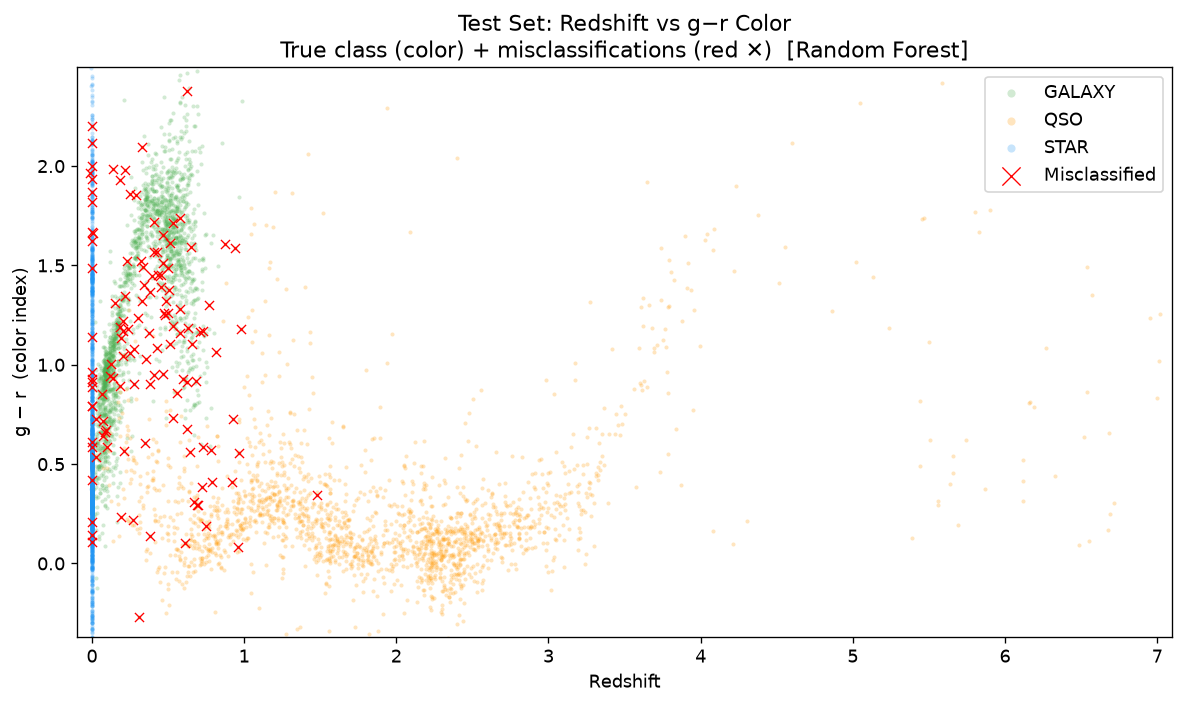

Saved: results/figures/scatter_redshift_vs_gr.png


In [21]:
class_colors = {'STAR': '#2196F3', 'GALAXY': '#4CAF50', 'QSO': '#FF9800'}

fig, ax = plt.subplots(figsize=(10, 6))

for cls in classes:
    mask = test_df['y_true'] == cls
    ax.scatter(
        test_df.loc[mask, 'redshift'],
        test_df.loc[mask, 'g_r'],
        c=class_colors[cls], label=cls, alpha=0.25, s=6, linewidths=0
    )

# Overlay misclassified
wrong_mask = ~test_df['correct']
ax.scatter(
    test_df.loc[wrong_mask, 'redshift'],
    test_df.loc[wrong_mask, 'g_r'],
    c='red', marker='x', s=30, linewidths=0.8,
    label='Misclassified', zorder=5
)

ax.set_xlabel('Redshift')
ax.set_ylabel('g − r  (color index)')
ax.set_title(f'Test Set: Redshift vs g−r Color\nTrue class (color) + misclassifications (red ✕)  [{best_model_name}]')
ax.legend(markerscale=2)
ax.set_xlim(-0.1, 7.1)
ax.set_ylim(test_df['g_r'].quantile(0.005), test_df['g_r'].quantile(0.995))
plt.tight_layout()
plt.savefig('../results/figures/scatter_redshift_vs_gr.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/scatter_redshift_vs_gr.png')

## 11. Feature-Set Accuracy Bar Chart

A visual summary of how much each layer of features contributes to accuracy.

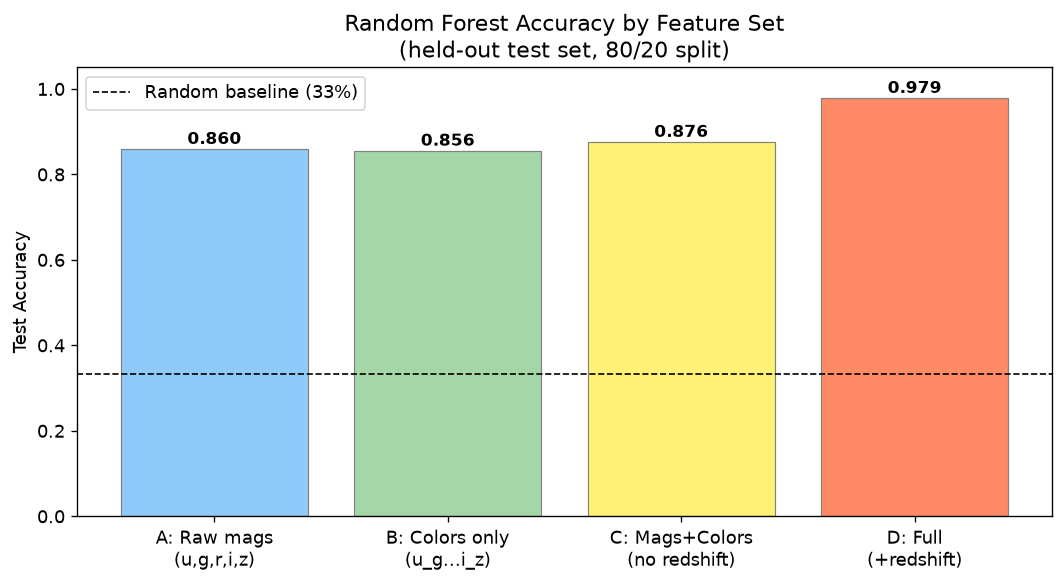

Saved: results/figures/feature_set_accuracy.png


In [22]:
bar_labels = [
    'A: Raw mags\n(u,g,r,i,z)',
    'B: Colors only\n(u_g…i_z)',
    'C: Mags+Colors\n(no redshift)',
    'D: Full\n(+redshift)',
]
bar_accs = [
    feat_comp_rows[0]['Test Accuracy'],
    feat_comp_rows[1]['Test Accuracy'],
    feat_comp_rows[2]['Test Accuracy'],
    ablation_results['D']['accuracy'],
]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#90CAF9', '#A5D6A7', '#FFF176', '#FF8A65']
bars = ax.bar(bar_labels, bar_accs, color=bar_colors, edgecolor='grey', linewidth=0.7)
for bar, acc in zip(bars, bar_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(0.333, color='black', linestyle='--', linewidth=1, label='Random baseline (33%)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Random Forest Accuracy by Feature Set\n(held-out test set, 80/20 split)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/feature_set_accuracy.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/feature_set_accuracy.png')

## 12. Wrap-Up

Final summary of all key numbers and a plain-English takeaway.

In [23]:
dummy_acc   = test_results['Dummy (most frequent)']['test_acc']
best_acc_D  = test_results[best_model_name]['test_acc']
best_acc_C  = ablation_results['C']['accuracy']
best_f1_D   = test_results[best_model_name]['macro_f1']

print('='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(f'Best model            : {best_model_name}')
print(f'Dummy baseline        : {dummy_acc:.4f}  (random chance on balanced data)')
print(f'Test accuracy (Set D) : {best_acc_D:.4f}  (with redshift)')
print(f'Test accuracy (Set C) : {best_acc_C:.4f}  (photometry only — NO redshift)')
print(f'Macro F1   (Set D)    : {best_f1_D:.4f}')
print(f'Hardest pair          : true={true_cls}, misclassified as {pred_cls}')
print()
print('='*60)

FINAL RESULTS SUMMARY
Best model            : Random Forest
Dummy baseline        : 0.3333  (random chance on balanced data)
Test accuracy (Set D) : 0.9790  (with redshift)
Test accuracy (Set C) : 0.8763  (photometry only — NO redshift)
Macro F1   (Set D)    : 0.9790
Hardest pair          : true=QSO, misclassified as GALAXY



In [24]:
import os
print('Output files:')
for root, dirs, files in os.walk('../results'):
    for f in sorted(files):
        full = os.path.join(root, f)
        size = os.path.getsize(full)
        print(f'  {full}  ({size:,} bytes)')

Output files:
  ../results\figures\confusion_matrix_best_model.png  (54,167 bytes)
  ../results\figures\feature_importances.png  (33,297 bytes)
  ../results\figures\feature_set_accuracy.png  (44,021 bytes)
  ../results\figures\scatter_redshift_vs_gr.png  (129,638 bytes)
  ../results\tables\feature_set_comparison.csv  (183 bytes)
  ../results\tables\model_comparison.csv  (341 bytes)
  ../results\tables\redshift_ablation.csv  (210 bytes)
